In [1]:
import re
import math
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
NIST_ORDER = [
    "Frequency",
    "BlockFrequency",
    "CumulativeSums",
    "Runs",
    "LongestRun",
    "Rank",
    "FFT",
    "NonOverlappingTemplate",
    "OverlappingTemplate",
    "Universal",
    "ApproximateEntropy",
    "RandomExcursions",
    "RandomExcursionsVariant", 
    "Serial",
    "LinearComplexity",
]

In [3]:
label_map = {
    3: "ER=3",
    5: "ER=5",
    "local": "Local entropy",
}

color_map = {
    3: "#ff7f0e",   # laranja
    5: "#2ca02c",   # verde
    "local": "#c5c9c7",  # cinza
}

def extract_er_from_path(path):
    name = path.name.lower()
    if "er3" in name:
        return 3
    elif "er5" in name:
        return 5
    elif "entropia_local" in name:
        return "local"
    else:
        return None


def parse_nist_report(report_path: Path) -> pd.DataFrame:
    text = report_path.read_text(errors="ignore")

    line_re = re.compile(
        r"""
        ^\s*
        (?:\d+\s+){10}
        (?P<pval>[0-9]*\.[0-9]+)
        (?:\s+\*)?
        \s+(?P<pass_num>\d+)\s*/\s*(?P<pass_den>\d+)
        \s+(?:\*\s+)?
        (?P<test>.+?)\s*$
        """,
        re.MULTILINE | re.VERBOSE
    )

    rows = []
    er = extract_er_from_path(report_path)

    for m in line_re.finditer(text):
        test = re.sub(r"\s+", " ", m.group("test").replace("*", "")).strip()

        rows.append({
            "er": er,
            "file": report_path.name,
            "test": test,
            "p_value": float(m.group("pval")),
            "pass_num": int(m.group("pass_num")),
            "pass_den": int(m.group("pass_den")),
        })

    if not rows:
        raise ValueError(f"Nenhum teste encontrado em {report_path.name}")

    df = pd.DataFrame(rows)
    df["proportion"] = df["pass_num"] / df["pass_den"]
    return df


def aggregate_nist_reports(report_paths, agg_mode="worst") -> pd.DataFrame:
    df = pd.concat(
        [parse_nist_report(Path(p)) for p in report_paths],
        ignore_index=True
    )

    if agg_mode == "worst":
        agg = (
            df.groupby(["er", "test"], as_index=False)
              .agg(
                  p_value=("p_value", "min"),
                  proportion=("proportion", "min"),
                  pass_den=("pass_den", "max"),
                  n_rows=("p_value", "size"),
              )
        )
    elif agg_mode == "mean":
        agg = (
            df.groupby(["er", "test"], as_index=False)
              .agg(
                  p_value=("p_value", "mean"),
                  proportion=("proportion", "mean"),
                  pass_den=("pass_den", "max"),
                  n_rows=("p_value", "size"),
              )
        )
    else:
        raise ValueError("agg_mode deve ser 'worst' ou 'mean'")

    # Força presença dos 15 testes para cada ER.
    ers = agg["er"].unique()
    full_index = pd.MultiIndex.from_product(
        [ers, NIST_ORDER],
        names=["er", "test"]
    )

    agg = (
        agg.set_index(["er", "test"])
           .reindex(full_index)
           .reset_index()
    )

    agg["test_id"] = agg["test"].map(
        {test: i + 1 for i, test in enumerate(NIST_ORDER)}
    )

    return agg

In [4]:
def plot_nist_reports_by_er(
    report_paths,
    agg_mode="worst",
    alpha=0.01,
    output_pdf="nist_er_comparison.pdf",
):
    agg = aggregate_nist_reports(report_paths, agg_mode=agg_mode)

    ers = agg["er"].dropna().unique()
    x_base = list(range(1, 16))

    width = 0.22
    offsets = {
        er: (i - (len(ers) - 1) / 2) * width
        for i, er in enumerate(ers)
    }

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(14, 8),
        sharex=True
    )

    # Painel 1: p-values.
    for er in ers:
        sub = agg[agg["er"] == er].sort_values("test_id")
        x = [v + offsets[er] for v in x_base]

        ax1.bar(
            x,
            sub["p_value"],
            width=width,
            label = label_map.get(er, f"ER={er}"),
            color=color_map.get(er, "1f77b4"),
        )

    ax1.axhline(alpha, linewidth=2, linestyle="--", label=r"$\alpha=0.01$")
    ax1.set_yscale("log")
    ax1.set_ylabel("P-value", fontsize=18)
    ax1.tick_params(axis="y", labelsize=14)
    ax1.legend(fontsize=12, ncol=4)

    # Painel 2: proportion.
    for er in ers:
        sub = agg[agg["er"] == er].sort_values("test_id")
        x = [v + offsets[er] for v in x_base]

        ax2.scatter(
            x,
            sub["proportion"],
            s=70,
            label = label_map.get(er, f"ER={er}")
        )

        # Limite mínimo de proporção por ER e teste.
        min_pass_rate = sub["pass_den"].apply(
            lambda m: (
                1 - alpha - 3 * math.sqrt((1 - alpha) * alpha / m)
                if pd.notna(m) and m > 0
                else float("nan")
            )
        )

        ax2.plot(
            x,
            min_pass_rate,
            linewidth=1.5,
            linestyle="--",
        )

    ax2.set_ylabel("Proportion", fontsize=18)
    ax2.set_xlabel("NIST SP 800-22 statistical test index", fontsize=18)
    ax2.set_ylim(0.6, 1.001)
    ax2.tick_params(axis="both", labelsize=14)

    # Eixo x fixo: sempre 1 a 15, mesmo quando não há valor.
    ax2.set_xticks(x_base)
    ax2.set_xticklabels([str(i) for i in x_base], fontsize=14)

    plt.tight_layout()
    plt.savefig(output_pdf, format="pdf", bbox_inches="tight")
    plt.show()

    return agg

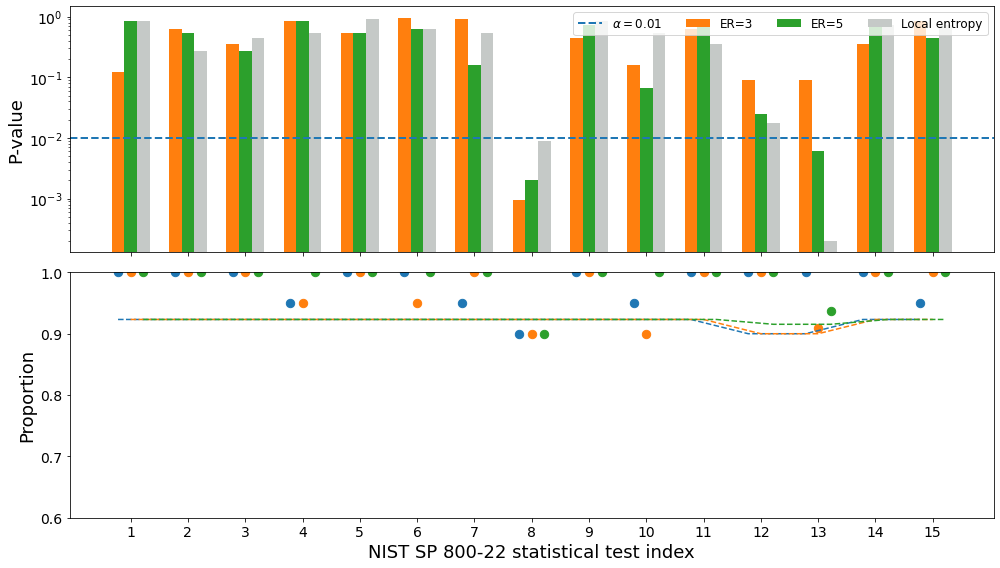

In [5]:
reports = [
    Path("pst/finalAnalysisReport_entropia_local.txt"),
    Path("pst/finalAnalysisReport_20M_er3.txt"),
    Path("pst/finalAnalysisReport_20M_er5.txt"),
]

agg_all = plot_nist_reports_by_er(
    reports,
    agg_mode="worst",
    alpha=0.01,
    output_pdf="local.pdf",
)

### Deixando apenas o do p-value

In [6]:
def plot_nist_pvalues_by_er(
    report_paths,
    agg_mode="worst",
    alpha=0.01,
    output_pdf="nist_pvalues_only.pdf",
    last_plot = False,
):
    agg = aggregate_nist_reports(report_paths, agg_mode=agg_mode)

    ers = agg["er"].dropna().unique()
    x_base = list(range(1, 16))

    width = 0.22
    offsets = {
        er: (i - (len(ers) - 1) / 2) * width
        for i, er in enumerate(ers)
    }

    fig, ax = plt.subplots(figsize=(14, 5))

    for er in ers:
        sub = agg[agg["er"] == er].sort_values("test_id")
        x = [v + offsets[er] for v in x_base]

        ax.bar(
            x,
            sub["p_value"],
            width=width,
            label = label_map.get(er, f"ER={er}"),
            color=color_map.get(er, "1f77b4"),
        )

    ax.axhline(alpha, linestyle="--", linewidth=2, label=r"$\alpha=0.01$")

    ax.set_yscale("log")

    # eixo y fixo até 10^-3
    ax.set_ylim(1e-3, 1.2)

    ax.set_ylabel("P-value", fontsize=18)
    
    if last_plot:
        ax.set_xlabel("NIST SP 800-22 statistical test index", fontsize=18)

    ax.set_xticks(x_base)
    ax.set_xticklabels([str(i) for i in x_base], fontsize=18)

    ax.tick_params(axis="y", labelsize=12)

    if not last_plot:
        # legenda fora do gráfico
        ax.legend(
            fontsize=18,
            ncol=4, loc="upper center",
            bbox_to_anchor=(0.5, 1.16),
            # loc="center left",          
            # bbox_to_anchor=(1.02, 0.5), # coloca à direita do eixo
            frameon=True,
        )

    plt.tight_layout()
    plt.savefig(output_pdf, format="pdf", bbox_inches="tight")
    plt.show()

    return agg

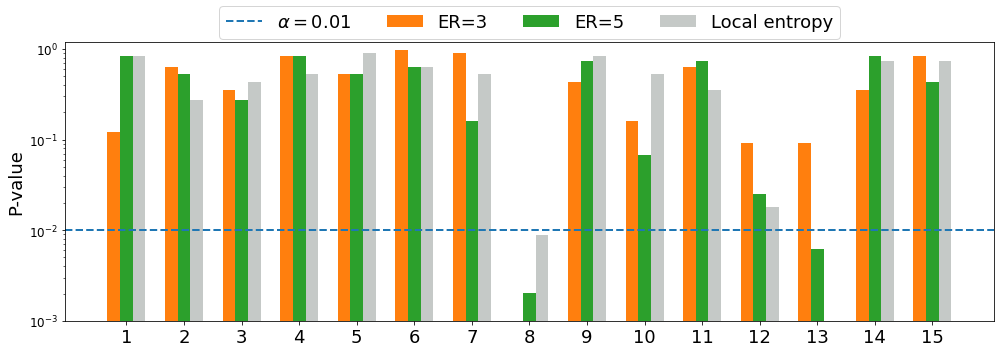

In [7]:
reports = [
    # Path("pst/finalAnalysisReport_er1.txt"),
    # Path("pst/finalAnalysisReport_er3.txt"),
    # Path("pst/finalAnalysisReport_er5.txt"),
    Path("pst/finalAnalysisReport_entropia_local.txt"),
    Path("pst/finalAnalysisReport_20M_er3.txt"),
    Path("pst/finalAnalysisReport_20M_er5.txt"),
]

agg_all = plot_nist_pvalues_by_er(
    reports,
    agg_mode="worst",
    alpha=0.01,
    output_pdf="nist_localEntropy_er3_er5_comparison.pdf",
)

### Rana 

In [8]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


def extract_kdf_from_path(path):
    name = Path(path).name.lower()

    if "argon2" in name:
        return "argon2"
    elif "pbkdf2" in name:
        return "pbkdf2"
    elif "hkdf" in name:
        return "hkdf"
    else:
        return "unknown"


def aggregate_with_kdf(report_paths, agg_mode="worst"):
    dfs = []

    for p in report_paths:
        df = aggregate_nist_reports([p], agg_mode=agg_mode)
        df["kdf"] = extract_kdf_from_path(p)
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)


def plot_nist_pvalues_by_kdf(
    report_paths,
    agg_mode="worst",
    alpha=0.01,
    output_pdf="nist_pvalues_by_kdf.pdf",
    last_plot=False,
):
    agg = aggregate_with_kdf(report_paths, agg_mode=agg_mode)

    kdf_order = ["argon2", "hkdf", "pbkdf2"]
    kdfs = [k for k in kdf_order if k in agg["kdf"].dropna().unique()]

    x_base = list(range(1, 16))

    width = 0.22
    offsets = {
        kdf: (i - (len(kdfs) - 1) / 2) * width
        for i, kdf in enumerate(kdfs)
    }

    label_map = {
        "argon2": "Argon2",
        "hkdf": "HKDF",
        "pbkdf2": "PBKDF2",
    }

    color_map = {
        "argon2": "#1f77b4", 
        "hkdf": "#e377c2",    
        "pbkdf2": "#7f7f7f",
    }

    fig, ax = plt.subplots(figsize=(14, 5))

    for kdf in kdfs:
        sub = agg[agg["kdf"] == kdf].sort_values("test_id")
        x = [v + offsets[kdf] for v in x_base]

        ax.bar(
            x,
            sub["p_value"],
            width=width,
            label=label_map.get(kdf, kdf),
            color=color_map.get(kdf, "#7f7f7f"),
        )

    ax.axhline(
        alpha,
        linestyle="--",
        linewidth=2,
        label=r"$\alpha=0.01$",
        color="black",
    )

    ax.set_yscale("log")
    ax.set_ylim(1e-3, 1.2)

    ax.set_ylabel("P-value", fontsize=18)

    if last_plot:
        ax.set_xlabel("NIST SP 800-22 statistical test index", fontsize=18)

    ax.set_xticks(x_base)
    ax.set_xticklabels([str(i) for i in x_base], fontsize=18)
    ax.tick_params(axis="y", labelsize=12)

    ax.legend(
        fontsize=18,
        ncol=4, loc="upper center",
        bbox_to_anchor=(0.5, 1.18),
        # loc="center left",          
        # bbox_to_anchor=(1.02, 0.5), # coloca à direita do eixo
        frameon=True,
    )

    plt.tight_layout()
    plt.savefig(output_pdf, format="pdf", bbox_inches="tight")
    plt.show()

    return agg

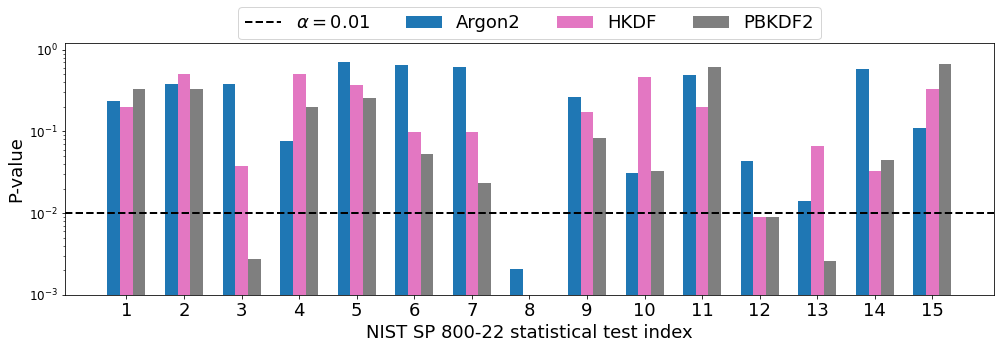

In [9]:
reports = [
    Path("pst/finalAnalysisReport_rana_er3_argon2.txt"),
    Path("pst/finalAnalysisReport_rana_er3_hkdf.txt"),
    Path("pst/finalAnalysisReport_rana_er3_pbkdf2.txt"),
]

agg_all = plot_nist_pvalues_by_kdf(
    reports,
    agg_mode="worst",
    alpha=0.01,
    output_pdf="nist_kdf_comparison_rana.pdf",
    last_plot=True,
)

In [10]:
agg_all

,er,test,p_value,proportion,pass_den,n_rows,test_id,kdf
0,3,Frequency,0.236810,1.000000,50,1,1,argon2
1,3,BlockFrequency,0.383827,1.000000,50,1,2,argon2
2,3,CumulativeSums,0.383827,1.000000,50,2,3,argon2
3,3,Runs,0.075719,1.000000,50,1,4,argon2
4,3,LongestRun,0.699313,1.000000,50,1,5,argon2
5,3,Rank,0.657933,1.000000,50,1,6,argon2
6,3,FFT,0.616305,0.980000,50,1,7,argon2
7,3,NonOverlappingTemplate,0.002043,0.940000,50,148,8,argon2
8,3,OverlappingTemplate,0.262249,0.980000,50,1,9,argon2
9,3,Universal,0.030806,1.000000,50,1,10,argon2
